This notebook trains 2 machine learning models.

The preprocessing of the transcription data includes:
- Removing the clinically irrelevant stopwords from the data
- Word embeddings is built by a custom fasttext model

The ML pipeline is structured like this:
- Split the data into a training and testing dataset.
- Have a cross validation of a linear SVC pipeline and a multinomial logistic regression
- Determine the model with the best test matrix and fit it on the training dataset.

In [2]:
# Import the required packages
import re

import numpy as np
import pandas as pd


In [3]:
# Load the required data
super_clinical_mtsamples = pd.read_csv("../data/super_clinical_mtsamples.csv")

In [4]:
# Load custom clinical stopwords
with open('../data/clinical-stopwords.txt', 'r') as file:
    custom_stopwords = set(file.read().splitlines())

def clean_and_tokenize(text):
    """Lowercase, remove punctuation/numbers, remove stopwords. No lemmatization."""
    if not isinstance(text, str):
        return []
    
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    return [word for word in tokens if word not in custom_stopwords]

print("Tokenizing texts for FastText...")
super_clinical_mtsamples['fasttext_tokens'] = super_clinical_mtsamples['transcription'].apply(clean_and_tokenize)

Tokenizing texts for FastText...


In [5]:
# Import the library required to build a fasttext vectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import FastText

In [6]:
# Build a custom fasttext vectorizer
class AverageFastTextVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10, min_n=3, max_n=6):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.min_n = min_n
        self.max_n = max_n
        self.model = None

    def fit(self, X, y=None):
        # FastText handles multiprocessing internally. 
        # Setting workers=4 takes advantage of a MacBook's multi-core architecture.
        self.model = FastText(
            sentences=X, 
            vector_size=self.vector_size, 
            window=self.window, 
            min_count=self.min_count,
            epochs=self.epochs,
            min_n=self.min_n,
            max_n=self.max_n,
            workers=4 
        )
        return self

    def transform(self, X, y=None):
        doc_vectors = []
        for doc in X:
            valid_words = [self.model.wv[word] for word in doc if word in self.model.wv]
            if valid_words:
                doc_vectors.append(np.mean(valid_words, axis=0))
            else:
                doc_vectors.append(np.zeros(self.vector_size))
        
        return np.array(doc_vectors)

In [ ]:
# Import the libraries required for splitting, training and testing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import LinearSVC
import warnings


In [8]:
# Splitting data
# Define features and target
X_ft = super_clinical_mtsamples['fasttext_tokens']
y_ft = super_clinical_mtsamples['clinical_superclass']

# Train/Test Split (30% holdout)
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_ft, y_ft, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_ft
)

In [9]:
# Run the FastText vectorizer
# Instantiate the vectorizer (using default or best parameters found earlier)
print("Training FastText model and extracting embeddings...")
ft_vectorizer = AverageFastTextVectorizer(
    vector_size=100, 
    window=5, 
    min_count=2, 
    min_n=3, 
    max_n=6
)

# Fit FastText on training data and transform it into average vectors ONCE
X_train_embedded = ft_vectorizer.fit_transform(X_train_ft)

# Transform the test data to be held for final evaluation
X_test_embedded = ft_vectorizer.transform(X_test_ft)

Training FastText model and extracting embeddings...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [ ]:
# Define the hyperparameter grids for the classifiers
svc_param_grid = [
    {
        # Standard L2 regularization testing both loss functions
        'penalty': ['l2'], 
        'loss': ['hinge', 'squared_hinge'], 
        'C': [0.001, 0.01, 0.1, 1.0],
        'dual': ['auto']
    },
    {
        # L1 regularization (Lasso - forces feature selection) requires dual=False
        'penalty': ['l1'], 
        'loss': ['squared_hinge'], 
        'C': [0.001, 0.01, 0.1, 1.0],
        'dual': [False]
    }
]

# LogisticRegression hyperparamters
logreg_param_grid = [
    {
        # Standard L2 penalty
        'penalty': ['l2'], 
        'solver': ['lbfgs', 'saga'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0]
    },
    {
        # L1 penalty (Lasso)
        'penalty': ['l1'], 
        'solver': ['saga'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0]
    }
]

# Suppress convergence warnings during the grid search
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Tune LinearSVC
print("Running GridSearchCV for LinearSVC...")
svc_grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42, max_iter=3000),
    param_grid=svc_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svc_grid.fit(X_train_embedded, y_train_ft)

# 2. Tune Logistic Regression
print("Running GridSearchCV for Logistic Regression...")
logreg_grid = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=3000
    ),
    param_grid=logreg_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
logreg_grid.fit(X_train_embedded, y_train_ft)

# 3. Compare the optimized results
print("\n--- Optimized Cross-Validation Results ---")
print(f"Best LinearSVC F1-Macro: {svc_grid.best_score_:.4f}")
print("LinearSVC Best Params:", svc_grid.best_params_)

print(f"\nBest LogReg F1-Macro:    {logreg_grid.best_score_:.4f}")
print("LogReg Best Params:", logreg_grid.best_params_)

Running GridSearchCV for LinearSVC...


/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Residential-training-2026/project_5/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Residential-training-2026/project_5/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Residential-training-2026/project_5/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Resi

Running GridSearchCV for Logistic Regression...


/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Residential-training-2026/project_5/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/mwagwabi/Library/CloudStorage/OneDrive-KemriWellcomeTrust/eneza_datacamp/Eneza-Data-Science-Residential-training-2026/project_5/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat


--- Optimized Cross-Validation Results ---
Best LinearSVC F1-Macro: 0.5717
LinearSVC Best Params: {'C': 0.1, 'dual': 'auto', 'loss': 'squared_hinge', 'penalty': 'l2'}

Best LogReg F1-Macro:    0.5462
LogReg Best Params: {'C': 0.5, 'penalty': 'l1', 'solver': 'saga'}


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
# 1. Instantiate the winning model with the optimized hyperparameter
final_svc_model = LinearSVC(
    C=0.1, 
    # dual='auto', # Auto is the default
    loss='squared_hinge',
    penalty='l2',
    class_weight='balanced', 
    random_state=42, 
    max_iter=3000
)

# 2. Fit the model on the full training embeddings
print("Fitting the final LinearSVC model...")
final_svc_model.fit(X_train_embedded, y_train_ft)

# 3. Generate predictions on the holdout test embeddings
print("Generating predictions on test data...")
y_pred_final = final_svc_model.predict(X_test_embedded)

# 4. Print the final classification report
print("\n--- Final Test Set Evaluation ---")
print(classification_report(y_test_ft, y_pred_final))

Fitting the final LinearSVC model...
Generating predictions on test data...

--- Final Test Set Evaluation ---
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.45      0.52      0.48        87
internal_and_systemic_medicine       0.65      0.70      0.67       356
     neurology_and_behavioural       0.54      0.72      0.62        83
      rehab_and_applied_health       0.34      0.54      0.41        56
       surgical_and_procedural       0.84      0.70      0.76       622

                      accuracy                           0.68      1204
                     macro avg       0.56      0.64      0.59      1204
                  weighted avg       0.71      0.68      0.69      1204



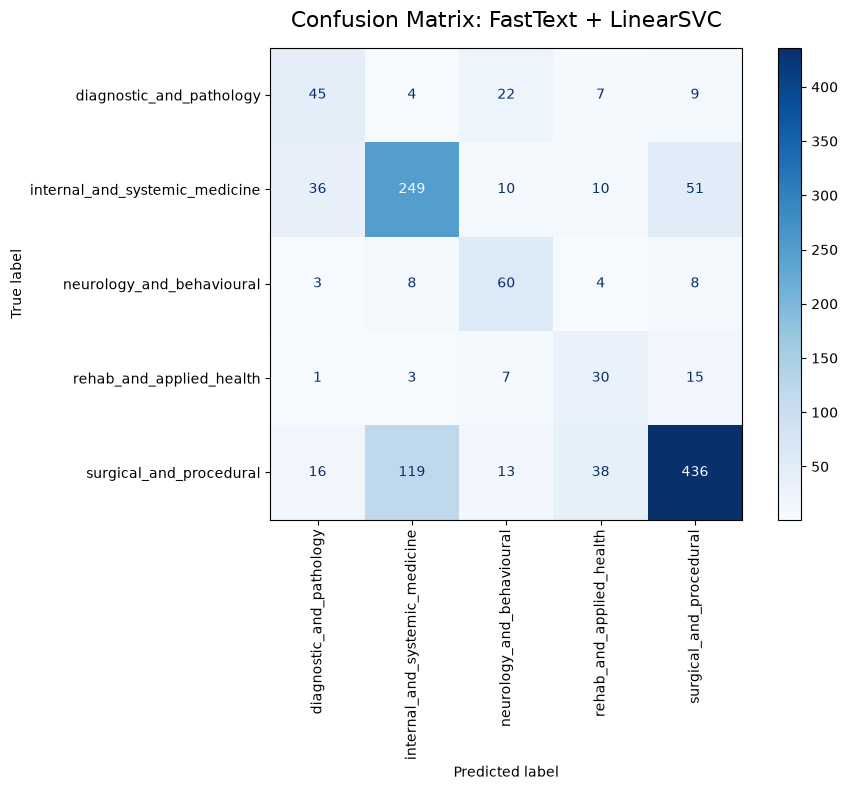

In [14]:
# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate and display the matrix
cm = confusion_matrix(y_test_ft, y_pred_final, labels=final_svc_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_svc_model.classes_)

# Apply a clean colormap and rotate the x-axis labels so they do not overlap
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)

# Add titles and formatting
plt.title('Confusion Matrix: FastText + LinearSVC', fontsize=16, pad=15)
plt.tight_layout()

# Render the plot
plt.show()